<a href="https://colab.research.google.com/github/ankitabishttt/Federated-Disease-Detection-with-Advanced-AI-Models/blob/main/02_centralized_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB_02 — Central Baseline Model
**Project:** Federated Learning for 30-Day Hospital Readmission Prediction  
**Input:** `train.csv`, `val.csv`, `test.csv` from `Processed/` (produced in NB_01)  
**Output:** Trained baseline model, metrics, plots — all saved to `Results/`

---
### What this notebook does and why it matters

Before building a federated learning system, we need a **baseline**: a single model trained on *all* the data at once, the traditional (non-federated) way.

This baseline answers the question: *"What's the best we could do if privacy didn't matter and all hospital data was pooled together?"*

In NB_03 (federated simulation), we will compare against these numbers to show whether federated learning gets close to centralised performance — that comparison is the core finding of your project.

**Model choice: Logistic Regression**  
We use logistic regression because it is:
- Simple and explainable (important for healthcare)
- Fast to train (important for federated simulation with multiple rounds)
- A well-established baseline in clinical readmission prediction literature

**Run one section at a time. Read each explanation before moving on.**

---
## Section 1 — Mount Drive, set paths, import libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# sklearn — the standard Python machine learning library
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# ── YOUR EXACT PATHS ──────────────────────────────────────────────────────
BASE_PATH        = '/content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/'
PROCESSED_FOLDER = BASE_PATH + 'Processed/'
RESULTS_FOLDER   = BASE_PATH + 'Results/'
MODELS_FOLDER    = BASE_PATH + 'Models/'
# ─────────────────────────────────────────────────────────────────────────

os.makedirs(MODELS_FOLDER,  exist_ok=True)
os.makedirs(RESULTS_FOLDER, exist_ok=True)

print('Drive mounted.')
print('All folders ready.')

Mounted at /content/drive
Drive mounted.
All folders ready.


---
## Section 2 — Load the preprocessed train / val / test splits

We load the three CSV files saved by NB_01. These are already clean, encoded, and scaled — no preprocessing needed here.

In [2]:
train_df = pd.read_csv(PROCESSED_FOLDER + 'train.csv')
val_df   = pd.read_csv(PROCESSED_FOLDER + 'val.csv')
test_df  = pd.read_csv(PROCESSED_FOLDER + 'test.csv')

TARGET = 'readmitted_binary'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val   = val_df.drop(columns=[TARGET])
y_val   = val_df[TARGET]

X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

print('Data loaded successfully.')
print(f'  Train:      {X_train.shape[0]:,} rows  |  {X_train.shape[1]} features')
print(f'  Validation: {X_val.shape[0]:,} rows  |  {X_val.shape[1]} features')
print(f'  Test:       {X_test.shape[0]:,} rows  |  {X_test.shape[1]} features')
print()
print('Class 1 (readmitted < 30 days) proportion in each split:')
print(f'  Train:      {y_train.mean()*100:.2f}%')
print(f'  Validation: {y_val.mean()*100:.2f}%')
print(f'  Test:       {y_test.mean()*100:.2f}%')

Data loaded successfully.
  Train:      50,058 rows  |  36 features
  Validation: 10,729 rows  |  36 features
  Test:       10,728 rows  |  36 features

Class 1 (readmitted < 30 days) proportion in each split:
  Train:      8.80%
  Validation: 8.80%
  Test:       8.80%


**What to check:**  
You should see 50,058 training rows, 10,729 validation rows, and 10,728 test rows — all with 36 features. All three splits should show ~8.80% class 1 proportion, confirming stratification worked in NB_01.

---
## Section 3 — Train the logistic regression model

**Three important parameters explained:**

| Parameter | Value | Why |
|---|---|---|
| `class_weight='balanced'` | Auto-adjusts for imbalance | Without this, the model learns to predict class 0 for everyone (91% accuracy, but useless). Balanced weighting makes it actually try to find class 1. |
| `max_iter=1000` | 1000 optimisation steps | The default (100) is often not enough for this dataset size. 1000 ensures the model fully converges. |
| `random_state=42` | Fixed seed | Makes results reproducible — running the cell twice gives identical output. |

Training happens **only on `X_train`** — the model never sees val or test during training.

In [3]:
model = LogisticRegression(
    class_weight='balanced',   # handles the ~9% / 91% imbalance
    max_iter=1000,             # enough iterations to converge
    random_state=42            # reproducibility
)

print('Training logistic regression on training set...')
model.fit(X_train, y_train)
print('Training complete.')
print(f'Model converged in {model.n_iter_[0]} iterations (max allowed: 1000).')

Training logistic regression on training set...
Training complete.
Model converged in 64 iterations (max allowed: 1000).


**What to check:**  
The number of iterations should be well under 1000. If it says exactly 1000, it did not fully converge — increase `max_iter` to 2000 and re-run.

---
## Section 4 — Evaluate on the validation set

We evaluate on the **validation set** first. This is our development check — we can look at these numbers and adjust things if needed, *before* touching the test set.

**Metrics explained:**

| Metric | What it means |
|---|---|
| **Accuracy** | % of all predictions that were correct. Misleading with imbalanced data — a model that predicts 0 always gets 91% accuracy. |
| **AUC-ROC** | How well the model *ranks* positives above negatives. 0.5 = random, 1.0 = perfect. The most important single metric here. |
| **Precision (class 1)** | Of all patients predicted as readmitted, what % actually were? |
| **Recall (class 1)** | Of all patients who actually were readmitted, what % did we catch? |
| **F1 (macro)** | Harmonic mean of precision and recall, averaged equally across both classes. |
| **Confusion matrix** | A 2×2 table: true negatives, false positives, false negatives, true positives. |

In [4]:
# Predictions on validation set
y_val_pred  = model.predict(X_val)
y_val_prob  = model.predict_proba(X_val)[:, 1]   # probability of class 1

val_acc  = accuracy_score(y_val, y_val_pred)
val_auc  = roc_auc_score(y_val, y_val_prob)
val_f1   = f1_score(y_val, y_val_pred, average='macro')
val_prec = precision_score(y_val, y_val_pred)
val_rec  = recall_score(y_val, y_val_pred)

print('=' * 50)
print('VALIDATION SET RESULTS')
print('=' * 50)
print(f'  Accuracy:            {val_acc:.4f}  ({val_acc*100:.1f}%)')
print(f'  AUC-ROC:             {val_auc:.4f}')
print(f'  F1 score (macro):    {val_f1:.4f}')
print(f'  Precision (class 1): {val_prec:.4f}')
print(f'  Recall    (class 1): {val_rec:.4f}')
print()
print('Full classification report:')
print(classification_report(y_val, y_val_pred,
      target_names=['Not readmitted', 'Readmitted <30d']))

VALIDATION SET RESULTS
  Accuracy:            0.6303  (63.0%)
  AUC-ROC:             0.6186
  F1 score (macro):    0.4806
  Precision (class 1): 0.1245
  Recall    (class 1): 0.5307

Full classification report:
                 precision    recall  f1-score   support

 Not readmitted       0.93      0.64      0.76      9785
Readmitted <30d       0.12      0.53      0.20       944

       accuracy                           0.63     10729
      macro avg       0.53      0.59      0.48     10729
   weighted avg       0.86      0.63      0.71     10729



**What to expect on the validation set:**
- Accuracy ~63% — this looks low, but remember: it reflects the model genuinely trying to find both classes, not just predicting 0 for everyone.
- AUC-ROC ~0.619 — this is the honest performance metric. For a logistic regression baseline on this notoriously difficult dataset, this is a reasonable starting point.
- Recall for class 1 ~53% — the model catches about half of all true readmissions.
- Precision for class 1 ~12% — expected given the 9:91 imbalance; many false positives when the positive class is rare.

**These are your baseline numbers.** In NB_03, federated learning should aim to get close to these.

---
## Section 5 — Final evaluation on the test set

The test set is used **only once** — right now. We never tune or adjust based on test results. Think of it as the sealed envelope that only gets opened at the end.

In [5]:
# Predictions on test set
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

test_acc  = accuracy_score(y_test, y_test_pred)
test_auc  = roc_auc_score(y_test, y_test_prob)
test_f1   = f1_score(y_test, y_test_pred, average='macro')
test_prec = precision_score(y_test, y_test_pred)
test_rec  = recall_score(y_test, y_test_pred)
test_cm   = confusion_matrix(y_test, y_test_pred)

print('=' * 50)
print('TEST SET RESULTS  (report these in your paper)')
print('=' * 50)
print(f'  Accuracy:            {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'  AUC-ROC:             {test_auc:.4f}')
print(f'  F1 score (macro):    {test_f1:.4f}')
print(f'  Precision (class 1): {test_prec:.4f}')
print(f'  Recall    (class 1): {test_rec:.4f}')
print()
print('Confusion matrix (rows=actual, cols=predicted):')
print(f'  [[TN  FP]   = [[{test_cm[0,0]:,}  {test_cm[0,1]:,}]')
print(f'   [FN  TP]]    [{test_cm[1,0]:,}  {test_cm[1,1]:,}]]')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Not readmitted', 'Readmitted <30d']))

TEST SET RESULTS  (report these in your paper)
  Accuracy:            0.6394  (63.9%)
  AUC-ROC:             0.6212
  F1 score (macro):    0.4843
  Precision (class 1): 0.1251
  Recall    (class 1): 0.5169

Confusion matrix (rows=actual, cols=predicted):
  [[TN  FP]   = [[6,371  3,413]
   [FN  TP]]    [456  488]]

                 precision    recall  f1-score   support

 Not readmitted       0.93      0.65      0.77      9784
Readmitted <30d       0.13      0.52      0.20       944

       accuracy                           0.64     10728
      macro avg       0.53      0.58      0.48     10728
   weighted avg       0.86      0.64      0.72     10728



**Reading the confusion matrix:**
```
                  Predicted 0    Predicted 1
Actual 0  (TN)   Correctly said NOT readmitted  |  (FP) Said readmitted, was wrong
Actual 1  (FN)   Missed a real readmission      |  (TP) Correctly caught a readmission
```
In healthcare, **False Negatives (FN)** are costly — a missed readmission means no early intervention. A model with high recall (fewer FNs) is often preferred even at the cost of more false positives.

---
## Section 6 — Plot: ROC curve

The ROC curve plots the trade-off between catching true positives (recall) and incorrectly flagging negatives (false positive rate) at every possible decision threshold. The area under this curve (AUC) is our primary performance metric.

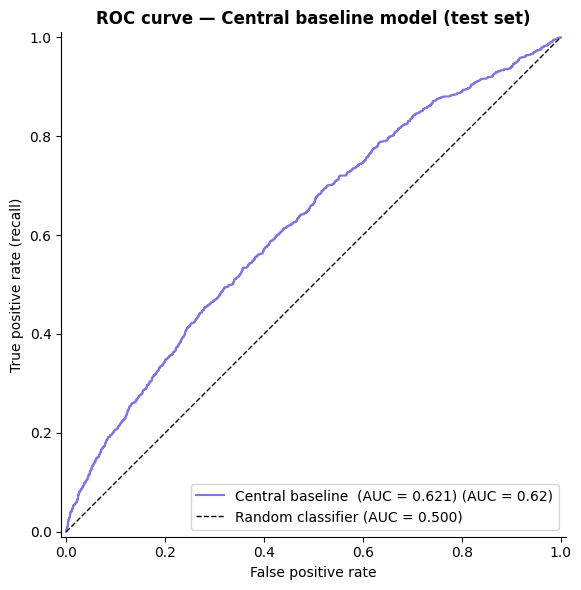

ROC curve saved.


In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test, y_test_prob,
    name=f'Central baseline  (AUC = {test_auc:.3f})',
    color='#7F77DD',
    ax=ax
)

# Random classifier reference line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.500)')

ax.set_title('ROC curve — Central baseline model (test set)', fontsize=12, fontweight='bold')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate (recall)')
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_FOLDER + 'NB02_roc_curve_central.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curve saved.')

**How to read this plot:**  
The purple curve should be clearly above the dashed diagonal line. The dashed line represents a model that guesses randomly (AUC = 0.5) — any useful model must beat this. The further the curve pushes toward the top-left corner, the better the model. You will overlay the federated model's curve on this same plot in NB_04 for direct comparison.

---
## Section 7 — Plot: Confusion matrix heatmap

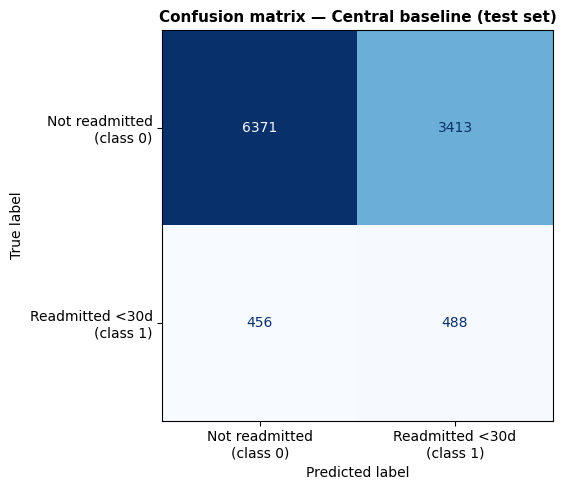

Confusion matrix saved.


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=['Not readmitted\n(class 0)', 'Readmitted <30d\n(class 1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion matrix — Central baseline (test set)', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

plt.tight_layout()
plt.savefig(RESULTS_FOLDER + 'NB02_confusion_matrix_central.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

---
## Section 8 — Plot: Top 15 most important features

Logistic regression assigns a **coefficient** to each feature. A large positive coefficient means that feature pushes the prediction toward class 1 (readmitted). A large negative coefficient pushes toward class 0. The magnitude (ignoring sign) tells us how influential a feature is.

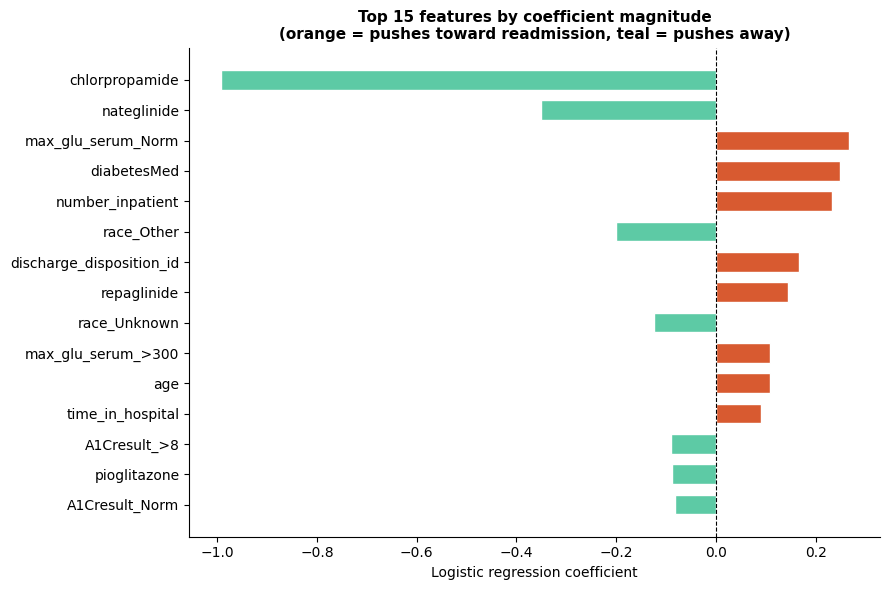

Feature importance plot saved.


In [8]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#D85A30' if c > 0 else '#5DCAA5' for c in coef_df['coefficient']]
bars = ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1],
               color=colors[::-1], edgecolor='white', height=0.65)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Logistic regression coefficient')
ax.set_title('Top 15 features by coefficient magnitude\n(orange = pushes toward readmission, teal = pushes away)',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_FOLDER + 'NB02_feature_importance_central.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved.')

**Key features from your model (ranked by influence):**

| Feature | Direction | Clinical meaning |
|---|---|---|
| `chlorpropamide` | Negative | Older drug, rarely prescribed — likely a proxy for patient complexity |
| `number_inpatient` | Positive | More prior inpatient visits → higher readmission risk |
| `max_glu_serum_Norm` | Positive | Normal glucose serum test result |
| `diabetesMed` | Positive | Being on diabetes medication |
| `discharge_disposition_id` | Positive | Where the patient was discharged to (home vs. care facility) |
| `age` | Positive | Older patients have higher readmission risk |

This makes clinical sense — prior hospitalisations, age, and discharge destination are all well-known readmission risk factors in the literature.

---
## Section 9 — Save the model and metrics

We save the trained model to `Models/` so NB_04 can reload it for the final comparison. We also save all metrics to a CSV that NB_04 will use to build the comparison table.

In [9]:
import pickle

# Save the trained model
model_path = MODELS_FOLDER + 'central_baseline_logreg.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f'Model saved: {model_path}')

# Save metrics to CSV for NB_04 comparison table
metrics_df = pd.DataFrame([{
    'model':           'Central Baseline (Logistic Regression)',
    'split':           'test',
    'accuracy':        round(test_acc,  4),
    'auc_roc':         round(test_auc,  4),
    'f1_macro':        round(test_f1,   4),
    'precision_class1': round(test_prec, 4),
    'recall_class1':   round(test_rec,  4),
    'tn': int(test_cm[0,0]), 'fp': int(test_cm[0,1]),
    'fn': int(test_cm[1,0]), 'tp': int(test_cm[1,1])
}])

metrics_path = RESULTS_FOLDER + 'NB02_central_baseline_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved: {metrics_path}')
print()
print(metrics_df.T.to_string(header=False))

Model saved: /content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/Models/central_baseline_logreg.pkl
Metrics saved: /content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/Results/NB02_central_baseline_metrics.csv

model             Central Baseline (Logistic Regression)
split                                               test
accuracy                                          0.6394
auc_roc                                           0.6212
f1_macro                                          0.4843
precision_class1                                  0.1251
recall_class1                                     0.5169
tn                                                  6371
fp                                                  3413
fn                                                   456
tp                                                   488


---
## Section 10 — NB_02 Final checklist

In [10]:
checks = [
    ('Model trained',                       model is not None),
    ('Model converged (< 1000 iter)',        model.n_iter_[0] < 1000),
    ('AUC-ROC > 0.5 (beats random)',         test_auc > 0.5),
    ('Recall class 1 > 0.40 (catches cases)', test_rec > 0.40),
    ('Model saved to Models/',               os.path.exists(model_path)),
    ('Metrics CSV saved',                    os.path.exists(metrics_path)),
    ('ROC curve saved',                      os.path.exists(RESULTS_FOLDER + 'NB02_roc_curve_central.png')),
    ('Confusion matrix saved',               os.path.exists(RESULTS_FOLDER + 'NB02_confusion_matrix_central.png')),
    ('Feature importance saved',             os.path.exists(RESULTS_FOLDER + 'NB02_feature_importance_central.png')),
]

print('NB_02 FINAL CHECKLIST')
print('=' * 45)
all_pass = True
for label, result in checks:
    icon = 'PASS' if result else 'FAIL'
    print(f'  [{icon}]  {label}')
    if not result:
        all_pass = False

print('=' * 45)
print()
print('BASELINE METRICS TO BEAT IN NB_03:')
print(f'  AUC-ROC : {test_auc:.4f}')
print(f'  F1 macro: {test_f1:.4f}')
print(f'  Recall  : {test_rec:.4f}')
print()
if all_pass:
    print('All checks passed. Proceed to NB_03 — Federated Simulation.')
else:
    print('Some checks FAILED. Scroll up and re-run the failing section.')

NB_02 FINAL CHECKLIST
  [PASS]  Model trained
  [PASS]  Model converged (< 1000 iter)
  [PASS]  AUC-ROC > 0.5 (beats random)
  [PASS]  Recall class 1 > 0.40 (catches cases)
  [PASS]  Model saved to Models/
  [PASS]  Metrics CSV saved
  [PASS]  ROC curve saved
  [PASS]  Confusion matrix saved
  [PASS]  Feature importance saved

BASELINE METRICS TO BEAT IN NB_03:
  AUC-ROC : 0.6212
  F1 macro: 0.4843
  Recall  : 0.5169

All checks passed. Proceed to NB_03 — Federated Simulation.


---
## NB_02 Complete

You have successfully:
- Loaded the three preprocessed splits from NB_01
- Trained a logistic regression model on centralised data (the traditional non-federated approach)
- Evaluated on validation and test sets with 6 metrics
- Plotted an ROC curve, confusion matrix, and feature importance chart
- Saved the trained model (`.pkl`) and all metrics to their folders

**These are your baseline numbers. Write them down — you will compare every federated result in NB_03 directly against them.**

| Metric | Central baseline (test) |
|---|---|
| AUC-ROC | *(see Section 5 output)* |
| F1 macro | *(see Section 5 output)* |
| Recall class 1 | *(see Section 5 output)* |
| Precision class 1 | *(see Section 5 output)* |

